In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import numpy
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

In [2]:
rng = numpy.random.default_rng()

In [3]:
multiplier = 1

In [4]:
mean_spacing = 1000 * multiplier
mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

In [5]:
abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2
G = np.pi * (abar ** 2 - 1 / 3)

In [46]:
energy_dict = {}
data = []
mean = []
std = []
for mean_spacing in range(1, 2, 10):
    mean_x = 1
    mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

    ratios = []
    energies = []
    couplings = []
    ratio = []
    nn = []
    nnn = []

    level_spacing = []
    zero_point = []

    for i in range(5000):
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(400, mean_spacing, mean_coupling_strength)
        # W = rng.normal(0, mean_coupling_strength)
        # E = rng.normal(0, mean_spacing)
        argsort = np.argsort(np.abs(energy_GOE_mat))
        closest = argsort[0]
        W = W_mat[closest]
        E = energy_GOE_mat[closest]
        energies.append(E)
        couplings.append(W)
        ratio.append(abs(energy_GOE_mat[argsort[2]] / E))
        nn.append(energy_GOE_mat[argsort[1]])
        nnn.append(energy_GOE_mat[argsort[2]])

        # closest = 1
        if energy_GOE_mat[closest] > 0:
            # print(energy_GOE_mat[closest], energy_GOE_mat[closest-1])
            s = energy_GOE_mat[closest] - energy_GOE_mat[closest-1]
            level_spacing.append(s)
            zero_point.append(energy_GOE_mat[closest] / s)
        else:
            # print(energy_GOE_mat[closest+1], energy_GOE_mat[closest])
            s = energy_GOE_mat[closest+1] - energy_GOE_mat[closest]
            level_spacing.append(energy_GOE_mat[closest+1] - energy_GOE_mat[closest])
            zero_point.append(energy_GOE_mat[closest+1] / s)

    # plt.hist(nn)
    # plt.show()
    # plt.hist(nnn)
    # plt.show()
    mean.append(np.mean(np.array(energies)))
    std.append(np.std(np.array(energies)))


0.296471658543005 0.28872037882533963
0.15915494309189535
0.0847241842881965 0.08333333333333333
0.999756837956594


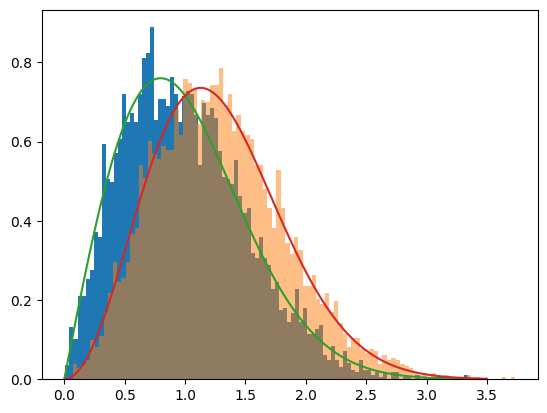

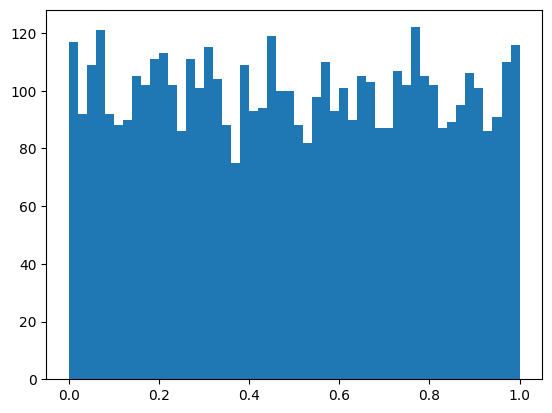

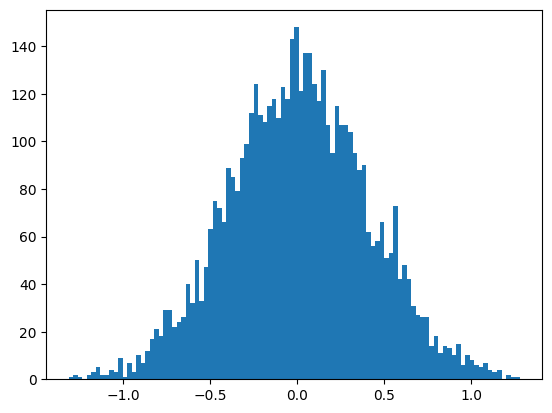

0.16036574697013656


In [73]:
rng = numpy.random.default_rng()
uniform_dist = np.array(rng.uniform(0, 1, 5000))
# transform uniform into a Wigner-Dyson distribution
nearest_neighbor = mean_spacing * np.sqrt(-4 / np.pi * np.log(1 - uniform_dist))

wigner = lambda s : np.pi * s / 2 * np.exp(-np.pi * s**2 / 4)
s = np.linspace(0, 3.5, 5000)
ds = s[1] - s[0]
test1 = lambda s : np.pi / 2 * s**2 * np.exp(-np.pi * s**2 / 4)

print(np.std(level_spacing)**2, 6/np.pi-16/np.pi**2)
print((6/np.pi-16/np.pi**2)/12+16/np.pi**2/12)
print(np.std(np.array(zero_point) - 0.5)**2, 1/12)

plt.hist(nearest_neighbor, bins=100, density=True)
plt.hist(level_spacing, bins=100, alpha=0.5, density=True)
plt.plot(s, wigner(s))
plt.plot(s, test1(s))
print(np.sum(test1(s)*ds))
plt.show()

plt.hist(zero_point, bins=50)
plt.show()

plt.hist(energies, bins=100)
plt.show()
print(np.std(energies)**2)

(1.0, 10.0)

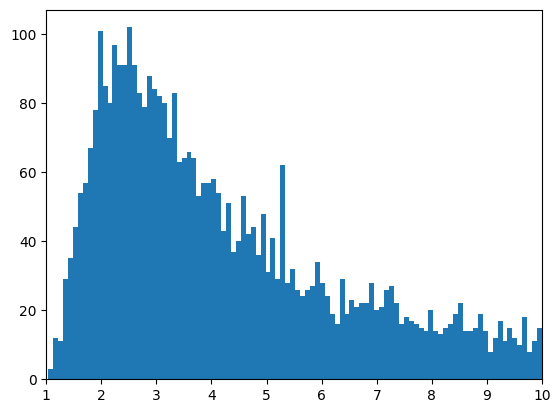

In [26]:
ratio = np.array(ratio)
plt.hist(ratio[ratio < 10], bins = 100)
plt.xlim(1, 10)

[np.float64(-0.006832048953697387), np.float64(-0.007502903801093629), np.float64(0.08121620232315381), np.float64(0.020295607761236102), np.float64(0.18674035612181825), np.float64(0.5525723838052119), np.float64(0.22247405185317648), np.float64(0.062660248660772), np.float64(-0.4146407929380324), np.float64(-0.2308496880328359)]
LinregressResult(slope=np.float64(0.4017941447847829), intercept=np.float64(-0.05107106511284698), rvalue=np.float64(0.9999656816868422), pvalue=np.float64(6.068256136400029e-18), stderr=np.float64(0.0011769221943293397), intercept_stderr=np.float64(0.06382565275244875))


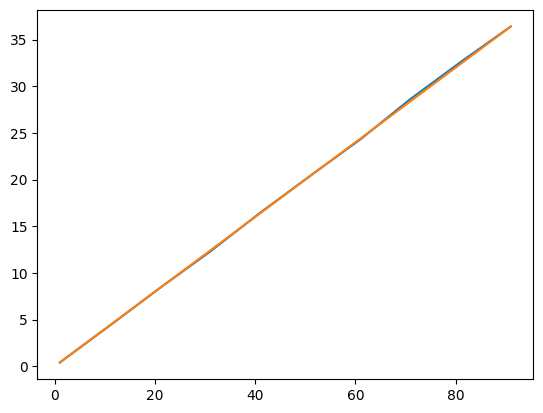

In [14]:
print(mean)
x = np.array(list(range(1, 100, 10)))
plt.plot(x, std)
plt.plot(x, x * 0.4)
res = sc.stats.linregress(x, std)
print(res)

In [10]:
energy_dict = {}
data = []
for temp in [1]:
    E0 = temp
    mean_spacing = 300
    mean_x = 1
    mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

    ratios = []
    energies = []
    couplings = []
    for i in range(5000):
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(400, mean_spacing, mean_coupling_strength)
        # W = rng.normal(0, mean_coupling_strength)
        # E = rng.normal(0, mean_spacing)
        closest = np.argmin(np.abs(energy_GOE_mat))
        W = W_mat[closest]
        E = energy_GOE_mat[closest]
        energies.append(E)
        couplings.append(W)
        
        # E0 = 5
        alpha = (1 + G * W ** 2 / multiplier) * E0 
        denom = (alpha - E) ** 2 + np.pi ** 2 * abar ** 2 * W ** 4 * E0 / multiplier
        Q = abar * np.pi * W ** 2 * (alpha + E) / denom / np.sqrt(E0)
        ratios.append(Q)
    # energy_dict[E0.item()] = ratios
    data.append(ratios)
    # break 

In [7]:
E0 = 10
W = mean_coupling_strength
E = alpha
print(mean_spacing)
print(alpha)

alpha = (1 + G * W ** 2 / multiplier) * E0 
denom = (alpha - E) ** 2 + np.pi ** 2 * abar ** 2 * W ** 4 * E0 / multiplier
print(G)
Q = abar * np.pi * W ** 2 * (alpha + E) / denom / np.sqrt(E0)
print(Q)

300
-0.5591603231719827
-0.3294275401504679
-0.04671062835588362


(array([  1.,   0.,   3.,  11.,  20.,  55., 136., 330., 493., 659., 787.,
        794., 686., 503., 283., 140.,  73.,  19.,   4.,   3.]),
 array([-536.94655836, -488.26906471, -439.59157105, -390.91407739,
        -342.23658373, -293.55909007, -244.88159641, -196.20410275,
        -147.5266091 ,  -98.84911544,  -50.17162178,   -1.49412812,
          47.18336554,   95.8608592 ,  144.53835286,  193.21584651,
         241.89334017,  290.57083383,  339.24832749,  387.92582115,
         436.60331481]),
 <BarContainer object of 20 artists>)

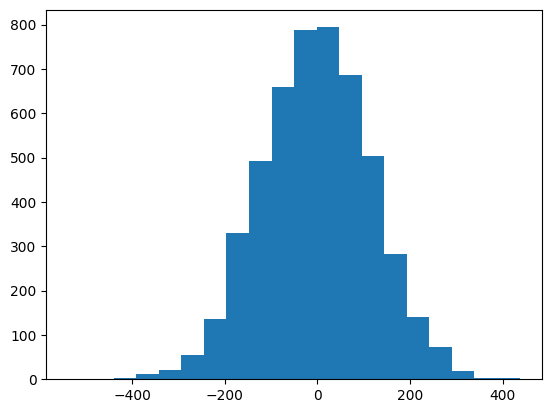

In [16]:
plt.hist(energies, bins=20)

In [64]:
E0 = 1
print(2 * G / (np.pi * abar * np.sqrt(E0)))

-0.43875523176521913


-0.07941453888700269
0.337651508491415
2320 2680


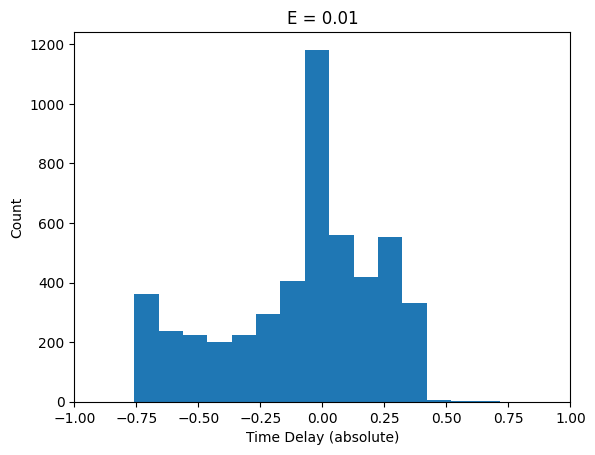

In [12]:
temps = [0.01]
i = 0
for ratios in data:
    ratios = np.array(ratios)
    print(np.mean(ratios))
    print(np.std(ratios))
    print((ratios > 0).sum(), (ratios < 0).sum())
    plt.hist(ratios, bins=100)
    plt.xlabel("Time Delay (absolute)")
    plt.ylabel("Count")
    plt.title(f"E = {temps[i]}")
    # plt.savefig(f"Figures/temp_{temps[i]}.pdf")
    plt.xlim([-1, 1])
    plt.show()
    i += 1

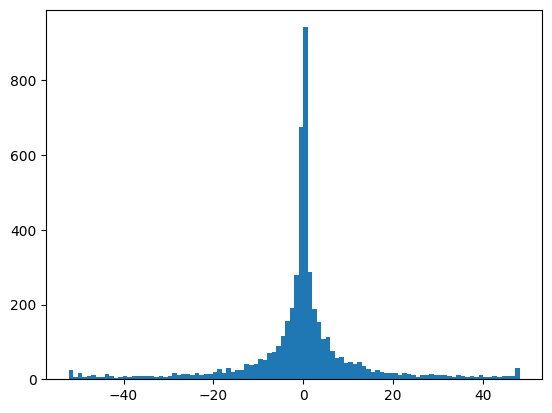

14.028035466303205


: 

In [ ]:
for E0 in energy_dict:
    plt.hist(energy_dict[E0], bins=100)
    plt.show()
# plt.xlim(-3 * std, 3 * std)
print(std)

(array([ 14.,  30., 128., 218., 245., 213., 103.,  41.,   7.,   1.]),
 array([-1118.65955305,  -864.36534533,  -610.07113761,  -355.77692989,
         -101.48272217,   152.81148555,   407.10569328,   661.399901  ,
          915.69410872,  1169.98831644,  1424.28252416]),
 <BarContainer object of 10 artists>)

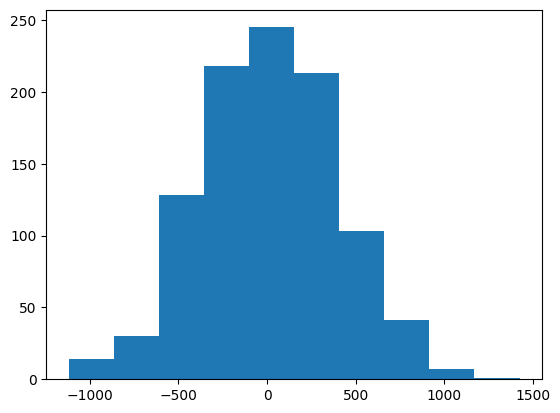

In [41]:
plt.hist(energies, bins=10)

(array([  1.,  13.,  60., 121., 269., 265., 178.,  67.,  20.,   6.]),
 array([-36.41102512, -29.35500053, -22.29897594, -15.24295135,
         -8.18692676,  -1.13090217,   5.92512242,  12.981147  ,
         20.03717159,  27.09319618,  34.14922077]),
 <BarContainer object of 10 artists>)

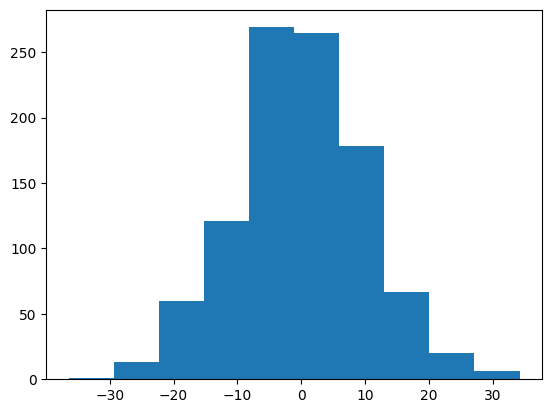

In [42]:
plt.hist(couplings, bins=10)